# Домашнее задание. Библиотека sklearn и классификация с помощью KNN

**Задача**: предсказать, выживет ли персонаж из Игры Престолов (`isAlive`).

**Метрика**: Accuracy

## Часть 1. Анализ и предобработка данных

### Задание 1.1. Импорт библиотек

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

RANDOM_STATE = 42

### Загрузка данных

In [2]:
os.makedirs('data', exist_ok=True)

gdown.download(id='1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v', output='data/game_of_thrones_train.csv', quiet=False)
gdown.download(id='1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3', output='data/game_of_thrones_test.csv', quiet=False)
gdown.download(id='1M14conWjAW2QLoyCXbHEAy8bql2f99eF', output='data/submission.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /Users/yarkiy/Documents/GitHub/MFTI/4.1 Домашнее задание. Основы машинного обучения/data/game_of_thrones_train.csv


  0%|          | 0.00/138k [00:00<?, ?B/s]

100%|██████████| 138k/138k [00:00<00:00, 449kB/s]

100%|██████████| 138k/138k [00:00<00:00, 448kB/s]

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /Users/yarkiy/Documents/GitHub/MFTI/4.1 Домашнее задание. Основы машинного обучения/data/game_of_thrones_test.csv


...

100%|██████████| 37.3k/37.3k [00:00<00:00, 283kB/s]

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /Users/yarkiy/Documents/GitHub/MFTI/4.1 Домашнее задание. Основы машинного обучения/data/submission.csv


  0%|          | 0.00/2.74k [00:00<?, ?B/s]

100%|██████████| 2.74k/2.74k [00:00<00:00, 12.3MB/s]

'data/submission.csv'

### Задание 1.2. Загрузка датасета в DataFrame

In [3]:
data = pd.read_csv('data/game_of_thrones_train.csv', index_col='S.No')
data_test = pd.read_csv('data/game_of_thrones_test.csv', index_col='S.No')

print(f'Train: {data.shape}')
print(f'Test: {data_test.shape}')
data.head()

Train: (1557, 25)
Test: (389, 24)


,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1557 entries, 1 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   str    
 1   title             717 non-null    str    
 2   male              1557 non-null   int64  
 3   culture           488 non-null    str    
 4   dateOfBirth       279 non-null    float64
 5   mother            18 non-null     str    
 6   father            22 non-null     str    
 7   heir              21 non-null     str    
 8   house             1176 non-null   str    
 9   spouse            200 non-null    str    
 10  book1             1557 non-null   int64  
 11  book2             1557 non-null   int64  
 12  book3             1557 non-null   int64  
 13  book4             1557 non-null   int64  
 14  book5             1557 non-null   int64  
 15  isAliveMother     18 non-null     float64
 16  isAliveFather     22 non-null     float64
 17  isAliv

In [5]:
# Статистика по категориальным признакам
data.describe(include='object').T

,count,unique,top,freq
name,1557,1557,Viserys II Targaryen,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


In [6]:
# Статистика по числовым признакам
data.describe(include=[np.number]).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


### Задание 1.3. Предобработка (очистка) данных

Анализ пропущенных значений.

In [7]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(1)
pd.DataFrame({'Пропуски': missing, '%': missing_pct}).query('Пропуски > 0').sort_values('%', ascending=False)

,Пропуски,%
mother,1539,98.8
isAliveMother,1539,98.8
heir,1536,98.7
isAliveHeir,1536,98.7
father,1535,98.6
isAliveFather,1535,98.6
spouse,1357,87.2
isAliveSpouse,1357,87.2
dateOfBirth,1278,82.1
age,1278,82.1


### Задание 1.4. Числовые признаки

**Признак popularity** — распределение и логарифмическое преобразование.

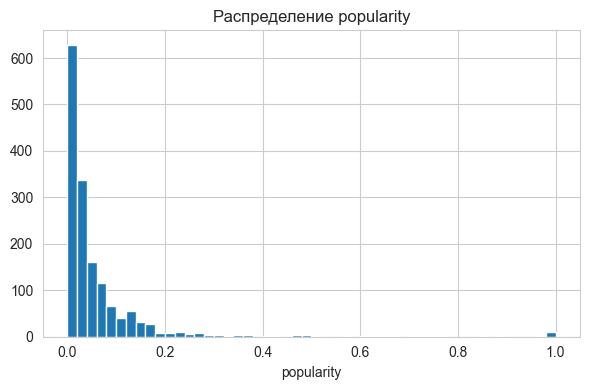

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
data['popularity'].hist(bins=50, ax=ax)
ax.set_title('Распределение popularity')
ax.set_xlabel('popularity')
plt.tight_layout()
plt.show()

# Popularity уже нормализован (0..1), дополнительные преобразования не нужны

In [9]:
# Popularity оставляем без преобразований — он уже в диапазоне [0, 1]
print(f"Popularity: min={data['popularity'].min():.4f}, max={data['popularity'].max():.4f}")

Popularity: min=0.0000, max=1.0000


**Признак numDeadRelations** — создаём бинарный признак `boolDeadRelations`.

In [10]:
print('Распределение numDeadRelations:')
print(data['numDeadRelations'].value_counts().sort_index())

data['boolDeadRelations'] = (data['numDeadRelations'] > 0).astype(int)
data_test['boolDeadRelations'] = (data_test['numDeadRelations'] > 0).astype(int)

Распределение numDeadRelations:
numDeadRelations
0     1488
1       24
2        4
3        4
4        7
5       10
6        3
7        7
8        2
9        1
10       4
11       1
12       1
15       1
Name: count, dtype: int64


**Признак age** — разделяем на `age_value` и `age_no_data`.

In [11]:
data['age_value'] = data['age'].fillna(0)
data['age_no_data'] = data['age'].isnull().astype(int)

data_test['age_value'] = data_test['age'].fillna(0)
data_test['age_no_data'] = data_test['age'].isnull().astype(int)

### Исправление ошибок в тестовых данных

In [12]:
print('Строки с отрицательным возрастом в тесте:')
neg_age = data_test.loc[data_test['age'] < 0]
if len(neg_age) > 0:
    print(neg_age[['age', 'dateOfBirth']])
else:
    print('Нет строк с отрицательным возрастом')

# Исправляем известные ошибки
if 1685 in data_test.index:
    data_test.loc[1685, 'dateOfBirth'] = 278.
    data_test.loc[1685, 'age'] = 0.
    data_test.loc[1685, 'age_value'] = 0.
if 1869 in data_test.index:
    data_test.loc[1869, 'dateOfBirth'] = 299.
    data_test.loc[1869, 'age'] = 0.
    data_test.loc[1869, 'age_value'] = 0.

Строки с отрицательным возрастом в тесте:
           age  dateOfBirth
S.No                       
1685 -277980.0     278279.0
1869 -298001.0     298299.0


### Задание 1.5. Категориальные признаки

**culture** — группировка народов в укрупнённые категории.

In [13]:
print('Уникальные значения culture:')
print(data['culture'].value_counts(dropna=False).head(20))

Уникальные значения culture:
culture
NaN                    1069
Northmen                 94
Ironborn                 91
Free Folk                45
Braavosi                 39
Valyrian                 28
Dornish                  17
Dothraki                 17
Ghiscari                 17
Reach                    13
Vale mountain clans      12
Rivermen                 10
Valemen                  10
northmen                  9
Westerman                 8
Free folk                 7
Tyroshi                   6
Qartheen                  5
Summer Isles              4
Astapori                  4
Name: count, dtype: int64


In [14]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

# Инвертируем словарь
cultures_grouped_inverted = {}
for k in cultures_grouped.keys():
    for v in cultures_grouped[k]:
        cultures_grouped_inverted.update({v: k})

data['culture_grouped'] = data['culture'].str.lower().str.strip().map(cultures_grouped_inverted)
data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')

data_test['culture_grouped'] = data_test['culture'].str.lower().str.strip().map(cultures_grouped_inverted)
data_test['culture_grouped'] = data_test['culture_grouped'].fillna('culture_no_data')

print('Распределение сгруппированных культур (train):')
print(data['culture_grouped'].value_counts())

Распределение сгруппированных культур (train):
culture_grouped
culture_no_data              1069
Essos Nations                 109
the North                     108
the Iron Islands               95
Other Nations                  57
Old Nations                    32
the Mountain and the Vale      25
Dorne                          21
the Rock                       14
the Reach                      13
the Isles and Rivers           10
the Stormlands                  4
Name: count, dtype: int64


**house** — оставляем топ-15 домов, остальные объединяем.

In [15]:
top_houses = data['house'].value_counts().head(15).index.tolist()

def group_house(h):
    if pd.isna(h):
        return 'house_no_data'
    elif h in top_houses:
        return h
    else:
        return 'Other'

data['house_grouped'] = data['house'].apply(group_house)
data_test['house_grouped'] = data_test['house'].apply(group_house)

print('Распределение домов (train):')
print(data['house_grouped'].value_counts())

Распределение домов (train):
house_grouped
Other                 703
house_no_data         381
House Frey             89
Night's Watch          88
House Stark            56
House Targaryen        40
House Lannister        36
House Tyrell           33
House Greyjoy          30
House Osgrey           20
Faith of the Seven     15
House Botley           12
House Hightower        12
House Arryn            11
House Martell          11
House Crakehall        10
House Florent          10
Name: count, dtype: int64


### Удаление исходных столбцов и one-hot кодирование

In [16]:
# Обработка isAliveSpouse: кодируем как 3 значения (0=мертв, 1=жив, -1=нет данных)
# Это сохраняет информацию для 13% персонажей, у которых есть данные о супруге
data['isAliveSpouse'] = data['isAliveSpouse'].fillna(-1).astype(int)
data_test['isAliveSpouse'] = data_test['isAliveSpouse'].fillna(-1).astype(int)

print('Распределение isAliveSpouse (train):')
print(data['isAliveSpouse'].value_counts())

# Удаляем столбцы, которые больше не нужны
cols_to_drop = [
    'name',  # идентификатор
    'title', 'spouse', 'father', 'mother', 'heir',  # высокая кардинальность
    'culture', 'house',  # заменены на сгруппированные версии
    'age', 'dateOfBirth',  # заменены на age_value + age_no_data
    # isAliveMother/Father/Heir — 98%+ NaN, слишком мало данных
    'isAliveMother', 'isAliveFather', 'isAliveHeir',
]

for col in cols_to_drop:
    if col in data.columns:
        data.drop(col, axis=1, inplace=True)
    if col in data_test.columns:
        data_test.drop(col, axis=1, inplace=True)

print(f'\nСтолбцы train: {list(data.columns)}')
print(f'Столбцы test: {list(data_test.columns)}')

Распределение isAliveSpouse (train):
isAliveSpouse
-1    1357
 1     158
 0      42
Name: count, dtype: int64

Столбцы train: ['male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isAliveSpouse', 'isMarried', 'isNoble', 'numDeadRelations', 'popularity', 'isAlive', 'boolDeadRelations', 'age_value', 'age_no_data', 'culture_grouped', 'house_grouped']
Столбцы test: ['male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isAliveSpouse', 'isMarried', 'isNoble', 'numDeadRelations', 'popularity', 'boolDeadRelations', 'age_value', 'age_no_data', 'culture_grouped', 'house_grouped']


### Задание 1.6. One-hot кодирование

In [17]:
cat_cols = ['culture_grouped', 'house_grouped']

data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)
data_test_encoded = pd.get_dummies(data_test, columns=cat_cols, drop_first=True)

# Разделяем признаки и целевую переменную
y_full = data_encoded['isAlive']
X_full = data_encoded.drop('isAlive', axis=1)

# Выравниваем столбцы train и test
missing_cols = set(X_full.columns) - set(data_test_encoded.columns)
for col in missing_cols:
    data_test_encoded[col] = 0

extra_cols = set(data_test_encoded.columns) - set(X_full.columns)
data_test_encoded.drop(list(extra_cols), axis=1, inplace=True, errors='ignore')
data_test_encoded = data_test_encoded[X_full.columns]

# Заполняем оставшиеся NaN нулями
X_full = X_full.fillna(0)
data_test_encoded = data_test_encoded.fillna(0)

print(f'X_full: {X_full.shape}, test: {data_test_encoded.shape}')
print(f'NaN train: {X_full.isnull().sum().sum()}, NaN test: {data_test_encoded.isnull().sum().sum()}')

X_full: (1557, 41), test: (389, 41)
NaN train: 0, NaN test: 0


### Задание 1.7-1.8. Анализ признаков и влияние на целевую переменную

Корреляция признаков с isAlive:
book4                               0.284014
numDeadRelations                   -0.198876
popularity                         -0.194187
house_grouped_House Targaryen      -0.187057
age_value                          -0.181938
boolDeadRelations                  -0.178177
culture_grouped_Old Nations        -0.173409
male                               -0.148290
house_grouped_Night's Watch        -0.123900
age_no_data                         0.113629
book1                              -0.112468
house_grouped_House Frey            0.071415
culture_grouped_the Iron Islands    0.064933
culture_grouped_the Rock           -0.063857
isNoble                            -0.060572
Name: isAlive, dtype: float64


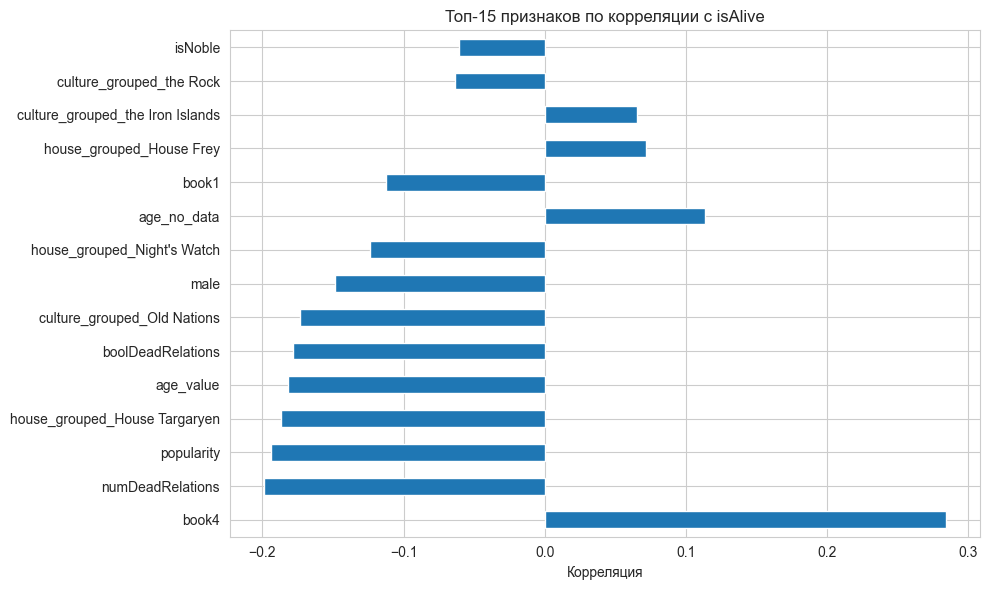

In [18]:
# Корреляция признаков с целевой переменной
corr_with_target = X_full.assign(isAlive=y_full).corr()['isAlive'].drop('isAlive').sort_values(key=abs, ascending=False)
print('Корреляция признаков с isAlive:')
print(corr_with_target.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
corr_with_target.head(15).plot(kind='barh', ax=ax)
ax.set_title('Топ-15 признаков по корреляции с isAlive')
ax.set_xlabel('Корреляция')
plt.tight_layout()
plt.show()

In [19]:
# Сравнение средних isAlive для бинарных признаков
binary_cols = ['male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried',
               'isNoble', 'boolDeadRelations', 'age_no_data']
binary_cols = [c for c in binary_cols if c in X_full.columns]

for col in binary_cols:
    print(f'\n{col}:')
    print(X_full.assign(isAlive=y_full).groupby(col)['isAlive'].mean())


male:
male
0    0.852433
1    0.727174
Name: isAlive, dtype: float64

book1:
book1
0    0.797166
1    0.662037
Name: isAlive, dtype: float64

book2:
book2
0    0.794651
1    0.745098
Name: isAlive, dtype: float64

book3:
book3
0    0.771751
1    0.787202
Name: isAlive, dtype: float64

book4:
book4
0    0.64464
1    0.88242
Name: isAlive, dtype: float64

book5:
book5
0    0.768936
1    0.797665
Name: isAlive, dtype: float64

isMarried:
isMarried
0    0.786293
1    0.725000
Name: isAlive, dtype: float64

isNoble:
isNoble
0    0.800687
1    0.750000
Name: isAlive, dtype: float64

boolDeadRelations:
boolDeadRelations
0    0.794355
1    0.434783
Name: isAlive, dtype: float64

age_no_data:
age_no_data
0    0.677419
1    0.800469
Name: isAlive, dtype: float64


### Задание 1.9-1.10. Формирование X, y и разделение на train/val

In [20]:
X = X_full.values
y = y_full.values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')
print(f'Баланс классов train: {np.mean(y_train):.3f}')
print(f'Баланс классов val: {np.mean(y_val):.3f}')

X_train: (1245, 41), X_val: (312, 41)
Баланс классов train: 0.778
Баланс классов val: 0.779


In [21]:
# Масштабирование (важно для LogReg, KNN, SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

## Часть 2. Обучение моделей

### Задание 2.1-2.2. Обучение нескольких моделей

In [22]:
# Модель 1: Logistic Regression (рекомендуемая в задании)
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_val_scaled)
acc_lr = accuracy_score(y_val, y_pred_lr)
print(f'Logistic Regression Accuracy: {acc_lr:.4f}')

Logistic Regression Accuracy: 0.7949


In [23]:
# Модель 2: Random Forest (ограничиваем глубину для предотвращения переобучения)
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
acc_rf = accuracy_score(y_val, y_pred_rf)
print(f'Random Forest Accuracy: {acc_rf:.4f}')

Random Forest Accuracy: 0.7853


In [24]:
# Модель 3: Gradient Boosting (консервативные параметры)
gb = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_val)
acc_gb = accuracy_score(y_val, y_pred_gb)
print(f'Gradient Boosting Accuracy: {acc_gb:.4f}')

Gradient Boosting Accuracy: 0.7981


In [25]:
# Модель 4: KNN
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_val_scaled)
acc_knn = accuracy_score(y_val, y_pred_knn)
print(f'KNN Accuracy: {acc_knn:.4f}')

KNN Accuracy: 0.7885


In [26]:
# Модель 5: Decision Tree (простая модель из списка в задании)
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_val)
acc_dt = accuracy_score(y_val, y_pred_dt)
print(f'Decision Tree Accuracy: {acc_dt:.4f}')

Decision Tree Accuracy: 0.7917


### Сравнение моделей

             Модель  Accuracy
  Gradient Boosting  0.798077
Logistic Regression  0.794872
      Decision Tree  0.791667
                KNN  0.788462
      Random Forest  0.785256


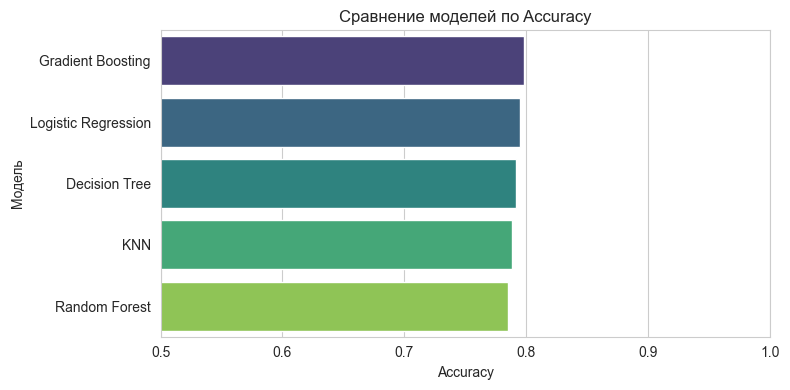

In [27]:
results = pd.DataFrame({
    'Модель': ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'KNN', 'Decision Tree'],
    'Accuracy': [acc_lr, acc_rf, acc_gb, acc_knn, acc_dt]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=results, x='Accuracy', y='Модель', ax=ax, palette='viridis')
ax.set_title('Сравнение моделей по Accuracy')
ax.set_xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

### Подбор гиперпараметров

Попробуем подобрать параметры для лучших моделей через cross-validation.
Используем небольшие сетки, чтобы избежать переобучения.

In [28]:
# GridSearch для Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

print(f'LogReg лучшие параметры: {grid_lr.best_params_}')
print(f'LogReg лучший CV Accuracy: {grid_lr.best_score_:.4f}')
print(f'LogReg Accuracy на валидации: {accuracy_score(y_val, grid_lr.predict(X_val_scaled)):.4f}')

# GridSearch для Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f'\nRF лучшие параметры: {grid_rf.best_params_}')
print(f'RF лучший CV Accuracy: {grid_rf.best_score_:.4f}')
print(f'RF Accuracy на валидации: {accuracy_score(y_val, grid_rf.predict(X_val)):.4f}')

# Выбираем лучшую модель по CV score
if grid_lr.best_score_ >= grid_rf.best_score_:
    best_model = grid_lr.best_estimator_
    best_name = 'Logistic Regression'
    best_needs_scaling = True
else:
    best_model = grid_rf.best_estimator_
    best_name = 'Random Forest'
    best_needs_scaling = False

print(f'\nЛучшая модель: {best_name} (CV Accuracy: {max(grid_lr.best_score_, grid_rf.best_score_):.4f})')

LogReg лучшие параметры: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
LogReg лучший CV Accuracy: 0.8193
LogReg Accuracy на валидации: 0.7788



RF лучшие параметры: {'max_depth': 7, 'n_estimators': 200}
RF лучший CV Accuracy: 0.8193
RF Accuracy на валидации: 0.7917

Лучшая модель: Logistic Regression (CV Accuracy: 0.8193)


## Часть 3. Оценка качества

### Задание 3.1. Метрики лучшей модели

Classification Report:
              precision    recall  f1-score   support

    Dead (0)       0.50      0.17      0.26        69
   Alive (1)       0.80      0.95      0.87       243

    accuracy                           0.78       312
   macro avg       0.65      0.56      0.56       312
weighted avg       0.74      0.78      0.73       312



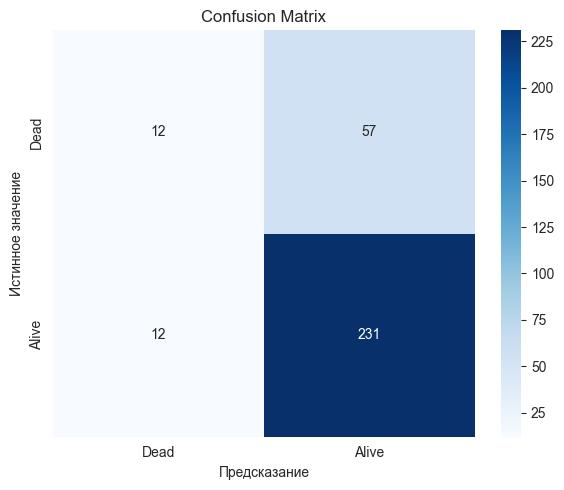

In [29]:
if best_needs_scaling:
    y_pred_best = best_model.predict(X_val_scaled)
else:
    y_pred_best = best_model.predict(X_val)

print('Classification Report:')
print(classification_report(y_val, y_pred_best, target_names=['Dead (0)', 'Alive (1)']))

cm = confusion_matrix(y_val, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Dead', 'Alive'], yticklabels=['Dead', 'Alive'])
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинное значение')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

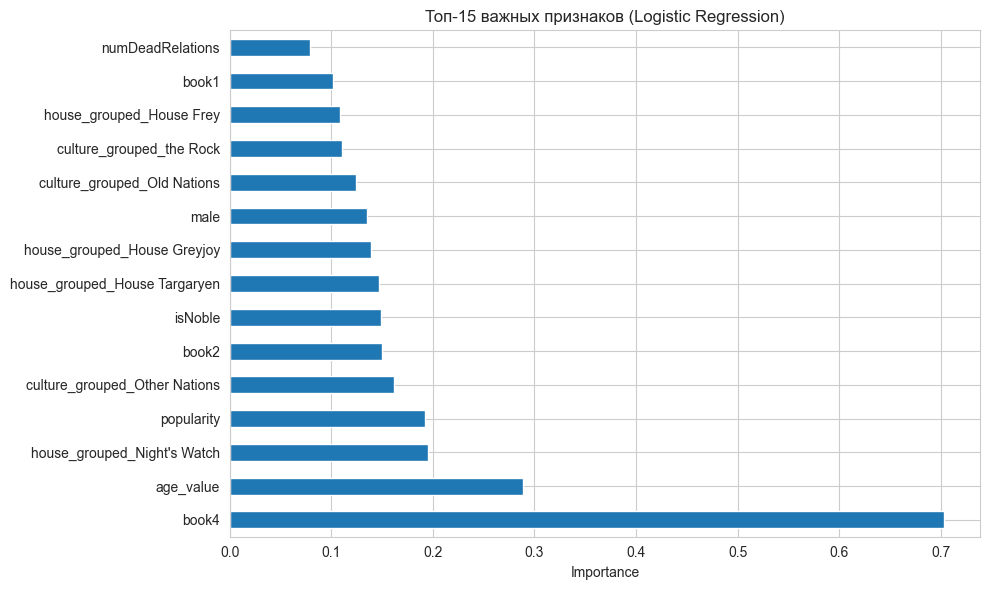

In [30]:
# Feature importance (если модель поддерживает)
if hasattr(best_model, 'feature_importances_'):
    feature_names = X_full.columns
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
elif hasattr(best_model, 'coef_'):
    feature_names = X_full.columns
    importances = np.abs(best_model.coef_[0])
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', ax=ax)
ax.set_title(f'Топ-15 важных признаков ({best_name})')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### Cross-validation на полном train

In [31]:
if best_needs_scaling:
    # Масштабируем весь X для cross-validation
    scaler_full = StandardScaler()
    X_scaled_full = scaler_full.fit_transform(X)
    cv_scores = cross_val_score(best_model, X_scaled_full, y, cv=5, scoring='accuracy')
else:
    cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')

print(f'CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'По фолдам: {cv_scores}')

CV Accuracy: 0.8009 ± 0.0177
По фолдам: [0.83333333 0.78205128 0.79421222 0.80385852 0.79099678]


### Финальное обучение и предсказание на test

In [32]:
# Обучаем финальную модель на всём train
if best_needs_scaling:
    scaler_final = StandardScaler()
    X_scaled = scaler_final.fit_transform(X)
    best_model.fit(X_scaled, y)
    X_test_final = scaler_final.transform(data_test_encoded.fillna(0).values)
else:
    best_model.fit(X, y)
    X_test_final = data_test_encoded.fillna(0).values

y_test_pred = best_model.predict(X_test_final)

print(f'Распределение предсказаний: 0={sum(y_test_pred==0)}, 1={sum(y_test_pred==1)}')

Распределение предсказаний: 0=79, 1=310


### Генерация submission.csv

In [33]:
submission = pd.read_csv('data/submission.csv', index_col='S.No')
submission['isAlive'] = y_test_pred
submission.to_csv('submission.csv', index=True)

print(f'submission.csv создан: {submission.shape}')
print(submission.head(10))
print(f'\nРаспределение предсказаний:')
print(submission['isAlive'].value_counts())

submission.csv создан: (389, 1)
      isAlive
S.No         
1558        0
1559        1
1560        1
1561        1
1562        1
1563        1
1564        1
1565        1
1566        1
1567        1

Распределение предсказаний:
isAlive
1    310
0     79
Name: count, dtype: int64
